폰트 'NanumGothic'가 성공적으로 로드되었습니다.


[*********************100%***********************]  9 of 9 completed


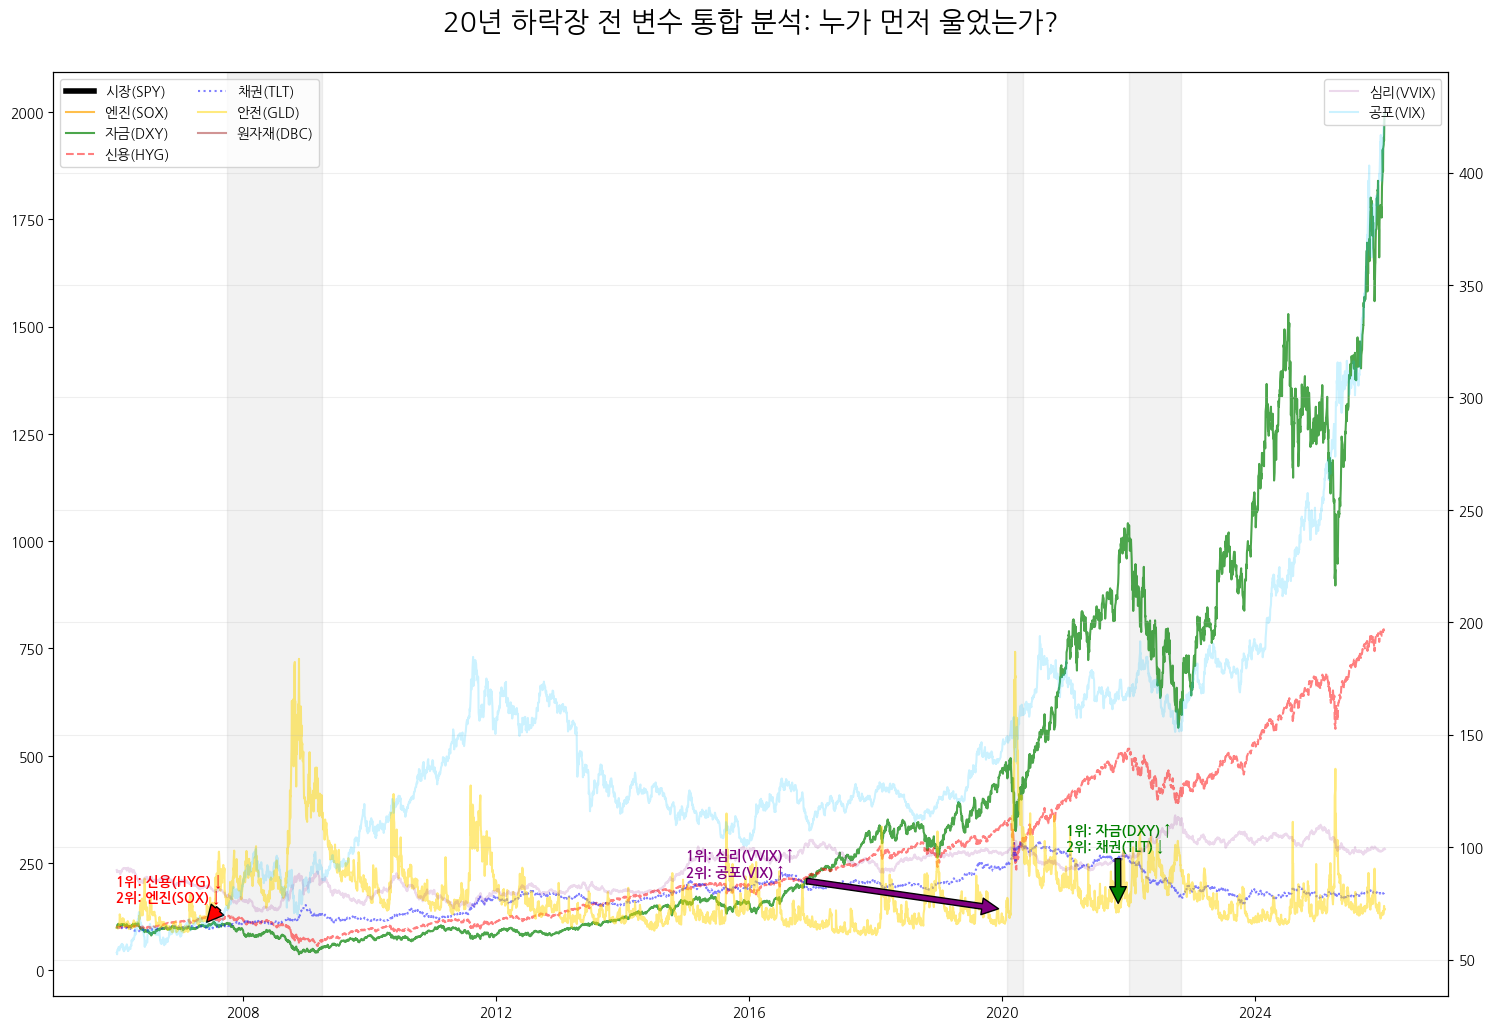

In [1]:
# 1. 코랩 한글 폰트 설치 및 설정 (※ 런타임 재시작 필수)
# 이 셀을 실행하기 전, 반드시 '런타임 > 런타임 다시 시작'을 먼저 해주세요.
!sudo apt-get install -y fonts-nanum > /dev/null
!sudo fc-cache -fv > /dev/null
!rm ~/.cache/matplotlib -rf

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # Import font_manager

# 1. 한글 설정 (윈도우용: Malgun Gothic, 맥: AppleGothic)
plt.rcParams['font.family'] = 'NanumGothic' # NanumGothic으로 설정
plt.rcParams['axes.unicode_minus'] = False

# Add a check to verify if the font is available and give explicit instructions
current_font_family = plt.rcParams['font.family']
if isinstance(current_font_family, list):
    primary_font_name = current_font_family[0] if current_font_family else ''
else:
    primary_font_name = current_font_family

if fm.findfont(primary_font_name):
    print(f"폰트 '{primary_font_name}'가 성공적으로 로드되었습니다.")
else:
    print(f"경고: 폰트 '{primary_font_name}'를 찾을 수 없습니다.")
    print("이전에 이 셀을 실행한 후 '런타임 > 런타임 다시 시작'을 하셨는지 확인해주세요.")
    print("런타임 재시작이 완료되면 한글이 정상적으로 표시될 것입니다.")


# 2. 전 변수 데이터 수집 (9대 핵심 지표)
tickers = {
    "시장(SPY)": "SPY",
    "심리(VVIX)": "^VVIX", "공포(VIX)": "^VIX",
    "엔진(SOX)": "SOXX", "자금(DXY)": "DX-Y.NYB",
    "신용(HYG)": "HYG", "채권(TLT)": "TLT",
    "안전(GLD)": "GLD", "원자재(DBC)": "DBC"
}

data = yf.download(list(tickers.values()), start="2006-01-01", auto_adjust=True)['Close']
data.columns = tickers.keys()
data = data.ffill()

# 3. 정규화 (시작점 100 기준) - VVIX, VIX 제외
norm_cols = [c for c in data.columns if c not in ["심리(VVIX)", "공포(VIX)"]]
norm = (data[norm_cols] / data[norm_cols].iloc[0]) * 100

# 4. 차트 생성
fig, ax1 = plt.subplots(figsize=(18, 12))

# [좌측 축] 가격 및 수급 지표 (각각의 선)
ax1.plot(norm.index, norm['시장(SPY)'], color='black', linewidth=4, label='시장(SPY)', zorder=10)
ax1.plot(norm.index, norm['엔진(SOX)'], color='orange', alpha=0.7, label='엔진(SOX)')
ax1.plot(norm.index, norm['자금(DXY)'], color='green', alpha=0.7, label='자금(DXY)')
ax1.plot(norm.index, norm['신용(HYG)'], color='red', linestyle='--', alpha=0.5, label='신용(HYG)')
ax1.plot(norm.index, norm['채권(TLT)'], color='blue', linestyle=':', alpha=0.5, label='채권(TLT)')
ax1.plot(norm.index, norm['안전(GLD)'], color='gold', alpha=0.5, label='안전(GLD)')
ax1.plot(norm.index, norm['원자재(DBC)'], color='brown', alpha=0.5, label='원자재(DBC)')

# [우측 축] 변동성 지표
ax2 = ax1.twinx()
ax2.plot(data.index, data['심리(VVIX)'], color='purple', alpha=0.15, label='심리(VVIX)')
ax2.plot(data.index, data['공포(VIX)'], color='deepskyblue', alpha=0.2, label='공포(VIX)')

# ---------------------------------------------------------
# 5. 하락장별 울음 순위 표시
# ---------------------------------------------------------

# 2008 리먼역 (1위: 신용, 2위: 엔진)
ax1.annotate('1위: 신용(HYG) ↓\n2위: 엔진(SOX) ↓', xy=(pd.to_datetime('2007-06-01'), 110),
             xytext=(pd.to_datetime('2006-01-01'), 160), color='red', weight='bold',
             arrowprops=dict(facecolor='red', shrink=0.05))

# 2020 코로나역 (1위: 심리, 2위: 공포)
ax1.annotate('1위: 심리(VVIX) ↑\n2위: 공포(VIX) ↑', xy=(pd.to_datetime('2020-02-12'), 140),
             xytext=(pd.to_datetime('2015-01-01'), 220), color='purple', weight='bold',
             arrowprops=dict(facecolor='purple', shrink=0.05))

# 2022 고금리역 (1위: 자금, 2위: 채권)
ax1.annotate('1위: 자금(DXY) ↑\n2위: 채권(TLT) ↓', xy=(pd.to_datetime('2021-11-01'), 150),
             xytext=(pd.to_datetime('2021-01-01'), 280), color='green', weight='bold',
             arrowprops=dict(facecolor='green', shrink=0.05))

# 배경 하이라이트
for name, s, e in [("2008 위기", "2007-10-01", "2009-04-01"),
                   ("2020 코로나", "2020-02-01", "2020-05-01"),
                   ("2022 하락", "2022-01-01", "2022-10-31")]:
    ax1.axvspan(pd.to_datetime(s), pd.to_datetime(e), color='gray', alpha=0.1)

ax1.set_title("20년 하락장 전 변수 통합 분석: 누가 먼저 울었는가?", fontsize=20, pad=30)
ax1.legend(loc='upper left', ncol=2); ax2.legend(loc='upper right')
plt.grid(True, alpha=0.2); plt.show()
